# Kalman Filter — Kansen & Betting Simulatie vs Polymarket
Converteert Kalman xG voorspellingen naar win/gelijk/verlies kansen via Poisson,
en simuleert €1 inzet per wedstrijd tegen Polymarket odds.

In [26]:
import os
os.chdir('C:/Users/semwi/FPL-Core-Insights/data')

import pandas as pd
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Stap 1 — Data laden

In [27]:
import os
os.chdir('C:/Users/semwi/FPL-Core-Insights/data')

kalman = pd.read_csv('training_data_with_kalman.csv')
kalman['timestamp'] = pd.to_datetime(kalman['timestamp'])

poly = pd.read_csv('polymarket_snapshots.csv')
poly['kickoff'] = pd.to_datetime(poly['kickoff'])
poly = poly[poly['prob_home'].notna() & (poly['prob_home'] != '')].copy()
poly['prob_home'] = poly['prob_home'].astype(float)
poly['prob_away'] = poly['prob_away'].astype(float)
poly['prob_draw'] = poly['prob_draw'].astype(float)

print(f'Kalman wedstrijden:     {len(kalman)}')
print(f'Polymarket wedstrijden: {len(poly)}')
poly[['home_team','away_team','kickoff','prob_home','prob_draw','prob_away']].head()

Kalman wedstrijden:     2661
Polymarket wedstrijden: 668


,home_team,away_team,kickoff,prob_home,prob_draw,prob_away
0,Manchester United,Fulham,2024-08-16 19:00:00,0.605,0.225,0.185
1,Ipswich Town,Liverpool,2024-08-17 11:30:00,0.105,0.170,0.745
2,Arsenal,Wolverhampton,2024-08-17 14:00:00,0.855,0.115,0.070
3,Brentford,Crystal Palace,2024-08-18 13:00:00,0.365,0.285,0.350
4,Fulham,Leicester City,2024-08-24 14:00:00,0.525,0.270,0.225


## Stap 2 — Kansen berekenen via Poisson
We gebruiken `kalman_xg_pred_home` en `kalman_xg_pred_away` als λ voor een Poisson verdeling.
Door alle scorecombinaties (0-0 t/m 8-8) op te tellen krijgen we P(thuis wint), P(gelijk), P(uit wint).

In [28]:
def dixon_coles_tau(goals_h, goals_a, lambda_h, lambda_a, rho=-0.13):
    """Correctie voor lage scores — vermindert gelijkspel overschatting."""
    if goals_h == 0 and goals_a == 0:
        return 1 - lambda_h * lambda_a * rho
    elif goals_h == 1 and goals_a == 0:
        return 1 + lambda_a * rho
    elif goals_h == 0 and goals_a == 1:
        return 1 + lambda_h * rho
    elif goals_h == 1 and goals_a == 1:
        return 1 - rho
    return 1.0

def xg_to_probabilities(lambda_home, lambda_away, max_goals=8, rho=-0.13):
    """
    Verbeterde versie met:
    1. Lambda scaling — Kalman onderschat xG systematisch (1.595 vs 1.679 werkelijk)
       Schaal omhoog met de verhouding werkelijk/voorspeld
    2. Dixon-Coles correctie voor lage scores
    """
    # Scaling factor gebaseerd op geobserveerde bias
    # Werkelijk: home=1.679, away=1.438 | Kalman: home=1.595, away=1.327
    SCALE_HOME = 1.679 / 1.595  # = 1.053
    SCALE_AWAY = 1.438 / 1.327  # = 1.084

    lambda_home = max(lambda_home * SCALE_HOME, 0.05)
    lambda_away = max(lambda_away * SCALE_AWAY, 0.05)

    prob_home = 0.0
    prob_draw = 0.0
    prob_away = 0.0

    for i in range(max_goals + 1):
        for j in range(max_goals + 1):
            p = (poisson.pmf(i, lambda_home) *
                 poisson.pmf(j, lambda_away) *
                 dixon_coles_tau(i, j, lambda_home, lambda_away, rho))
            if i > j:    prob_home += p
            elif i == j: prob_draw += p
            else:        prob_away += p

    total = prob_home + prob_draw + prob_away
    return prob_home / total, prob_draw / total, prob_away / total

# Vergelijk oud vs nieuw
print('Zonder correctie → Met correctie:')
for lh, la in [(1.8, 1.2), (1.5, 1.0), (1.2, 0.8), (0.3, 0.15)]:
    ph_oud = poisson.pmf
    ph, pd_, pa = xg_to_probabilities(lh, la)
    print(f'xG {lh:.1f} vs {la:.1f} → H:{ph:.3f} D:{pd_:.3f} A:{pa:.3f}')

Zonder correctie → Met correctie:
xG 1.8 vs 1.2 → H:0.500 D:0.250 A:0.250
xG 1.5 vs 1.0 → H:0.473 D:0.282 A:0.245
xG 1.2 vs 0.8 → H:0.439 D:0.323 A:0.238
xG 0.3 vs 0.1 → H:0.232 D:0.660 A:0.108


## Stap 3 — Kansen berekenen voor alle wedstrijden met Kalman features

In [29]:
# Alleen wedstrijden met Kalman features
kalman_valid = kalman[kalman['kalman_xg_pred_home'].notna()].copy()

probs = kalman_valid.apply(
    lambda row: xg_to_probabilities(row['kalman_xg_pred_home'], row['kalman_xg_pred_away']),
    axis=1
)

kalman_valid['kalman_prob_home'] = [p[0] for p in probs]
kalman_valid['kalman_prob_draw'] = [p[1] for p in probs]
kalman_valid['kalman_prob_away'] = [p[2] for p in probs]

print(f'Kansen berekend voor {len(kalman_valid)} wedstrijden')
kalman_valid[['home_team','away_team','kalman_xg_pred_home','kalman_xg_pred_away',
              'kalman_prob_home','kalman_prob_draw','kalman_prob_away']].head(8)

Kansen berekend voor 2581 wedstrijden


,home_team,away_team,kalman_xg_pred_home,kalman_xg_pred_away,kalman_prob_home,kalman_prob_draw,kalman_prob_away
0,Liverpool,Norwich City,0.221434,-0.071434,0.197750,0.764538,0.037712
1,West Ham United,Manchester City,0.071784,0.078216,0.066368,0.858752,0.074880
2,Bournemouth,Sheffield United,0.157445,-0.007445,0.145000,0.814376,0.040624
3,Burnley,Southampton,0.167614,-0.017614,0.153608,0.806245,0.040146
4,Watford,Brighton & Hove Albion,0.125699,0.024301,0.117559,0.840291,0.042150
5,Crystal Palace,Everton,0.144825,0.005175,0.134195,0.824582,0.041224
6,Tottenham Hotspur,Aston Villa,0.146581,0.003419,0.135706,0.823154,0.041140
7,Leicester City,Wolverhampton,0.163908,-0.013908,0.150481,0.809199,0.040320


## Stap 4 — Koppelen aan Polymarket data

In [30]:
# Merge op match_id
merged = poly.merge(
    kalman_valid[['match_id', 'kalman_prob_home', 'kalman_prob_draw', 'kalman_prob_away',
                  'kalman_xg_pred_home', 'kalman_xg_pred_away']],
    on='match_id',
    how='left'
)

# Als match_id niet werkt, merge op datum + teams
if merged['kalman_prob_home'].isna().all():
    print('Match op match_id mislukt, probeer datum + teams...')
    kalman_valid['date'] = kalman_valid['timestamp'].dt.date.astype(str)
    poly['date'] = poly['kickoff'].dt.date.astype(str)
    merged = poly.merge(
        kalman_valid[['date','home_team','away_team','kalman_prob_home',
                      'kalman_prob_draw','kalman_prob_away',
                      'kalman_xg_pred_home','kalman_xg_pred_away']],
        on=['date','home_team','away_team'],
        how='left'
    )

matched = merged['kalman_prob_home'].notna().sum()
print(f'Gekoppeld: {matched}/{len(merged)} wedstrijden')
merged[['home_team','away_team','prob_home','prob_draw','prob_away',
        'kalman_prob_home','kalman_prob_draw','kalman_prob_away']].head(8)

Gekoppeld: 668/668 wedstrijden


,home_team,away_team,prob_home,prob_draw,prob_away,kalman_prob_home,kalman_prob_draw,kalman_prob_away
0,Manchester United,Fulham,0.605,0.225,0.1850,0.420663,0.238681,0.340656
1,Ipswich Town,Liverpool,0.105,0.170,0.7450,0.098611,0.236662,0.664727
2,Arsenal,Wolverhampton,0.855,0.115,0.0700,0.854467,0.114850,0.030682
3,Brentford,Crystal Palace,0.365,0.285,0.3500,0.379774,0.274335,0.345891
4,Fulham,Leicester City,0.525,0.270,0.2250,0.334999,0.264878,0.400123
5,Southampton,Nottingham Forest,0.400,0.270,0.3100,0.285636,0.280361,0.434002
6,Manchester City,Ipswich Town,0.905,0.075,0.0255,0.950281,0.048325,0.001394
7,Aston Villa,Arsenal,0.190,0.235,0.5650,0.142594,0.200168,0.657239


## Stap 5 — Betting simulatie
**Strategie:** Zet €1 in op de uitkomst waar Kalman significant meer kans ziet dan Polymarket.
De Polymarket kansen zijn de impliciete odds: als Polymarket P(thuis)=0.40, dan betaalt €1 inzet €2.50 uit bij winst.

**Edge drempel:** Zet alleen in als Kalman > Polymarket + `EDGE_THRESHOLD`. Dit filtert wedstrijden waar het verschil groot genoeg is om te rechtvaardigen.

In [38]:
EDGE_THRESHOLD = 0.1 # Kalman moet minstens 5% meer kans zien dan Polymarket

sim = merged[merged['kalman_prob_home'].notna()].copy()

# Werkelijk resultaat
sim['home_goals'] = sim['home_goals'].astype(float)
sim['away_goals'] = sim['away_goals'].astype(float)

def actual_result(row):
    if row['home_goals'] > row['away_goals']:   return 'H'
    elif row['home_goals'] < row['away_goals']: return 'A'
    else:                                       return 'D'

sim['result'] = sim.apply(actual_result, axis=1)

results = []
bankroll = 0.0
bets_placed = 0

for _, row in sim.iterrows():
    bet_outcome = None
    edge = 0.0

    # Zoek uitkomst met grootste edge vs Polymarket
    edges = {
        'H': row['kalman_prob_home'] - row['prob_home'],
        'D': row['kalman_prob_draw'] - row['prob_draw'],
        'A': row['kalman_prob_away'] - row['prob_away'],
    }
    best = max(edges, key=edges.get)
    edge = edges[best]

    if edge >= EDGE_THRESHOLD:
        bet_outcome = best
        bets_placed += 1

        # Polymarket kans → implied odds
        poly_prob = row[f'prob_{"home" if best=="H" else "draw" if best=="D" else "away"}']
        odds = 1 / poly_prob  # bijv. prob=0.4 → odds=2.5

        # Winst of verlies
        if row['result'] == best:
            profit = odds - 1  # €1 inzet, odds-1 winst
        else:
            profit = -1.0      # €1 verloren

        bankroll += profit

        results.append({
            'match':       f"{row['home_team']} vs {row['away_team']}",
            'date':        row['kickoff'].strftime('%Y-%m-%d'),
            'bet':         best,
            'result':      row['result'],
            'edge':        round(edge, 3),
            'odds':        round(odds, 2),
            'profit':      round(profit, 2),
            'cumulative':  round(bankroll, 2),
            'won':         row['result'] == best,
        })

results_df = pd.DataFrame(results)
print(f'Wedstrijden beschikbaar: {len(sim)}')
print(f'Bets geplaatst:          {bets_placed}')
print(f'Totaal ingezet:          €{bets_placed:.2f}')
print(f'Netto resultaat:         €{bankroll:.2f}')
print(f'ROI:                     {bankroll/bets_placed*100:.1f}%' if bets_placed > 0 else '')
print(f'Win rate:                {results_df["won"].mean()*100:.1f}%')
results_df

Wedstrijden beschikbaar: 668
Bets geplaatst:          147
Totaal ingezet:          €147.00
Netto resultaat:         €27.80
ROI:                     18.9%
Win rate:                35.4%


,match,date,bet,result,edge,odds,profit,cumulative,won
0,Manchester United vs Fulham,2024-08-16,A,H,0.156,5.410,-1.000,-1.000,False
1,Fulham vs Leicester City,2024-08-24,A,H,0.175,4.440,-1.000,-2.000,False
2,Southampton vs Nottingham Forest,2024-08-24,A,A,0.124,3.230,2.230,0.230,True
3,Leicester City vs Aston Villa,2024-08-31,H,A,0.154,4.440,-1.000,-0.770,False
4,Ipswich Town vs Fulham,2024-08-31,A,D,0.204,2.470,-1.000,-1.770,False
...,...,...,...,...,...,...,...,...,...
142,Nottingham Forest vs Wolverhampton,2026-02-11,A,D,0.145,5.710,-1.000,28.630,False
143,West Ham United vs Bournemouth,2026-02-21,A,D,0.175,2.670,-1.000,27.630,False
144,Manchester City vs Newcastle United,2026-02-21,A,H,0.146,6.060,-1.000,26.630,False
145,Manchester United vs Crystal Palace,2026-03-01,A,H,0.147,6.900,-1.000,25.630,False


## Stap 6 — Visualisatie bankroll over de tijd

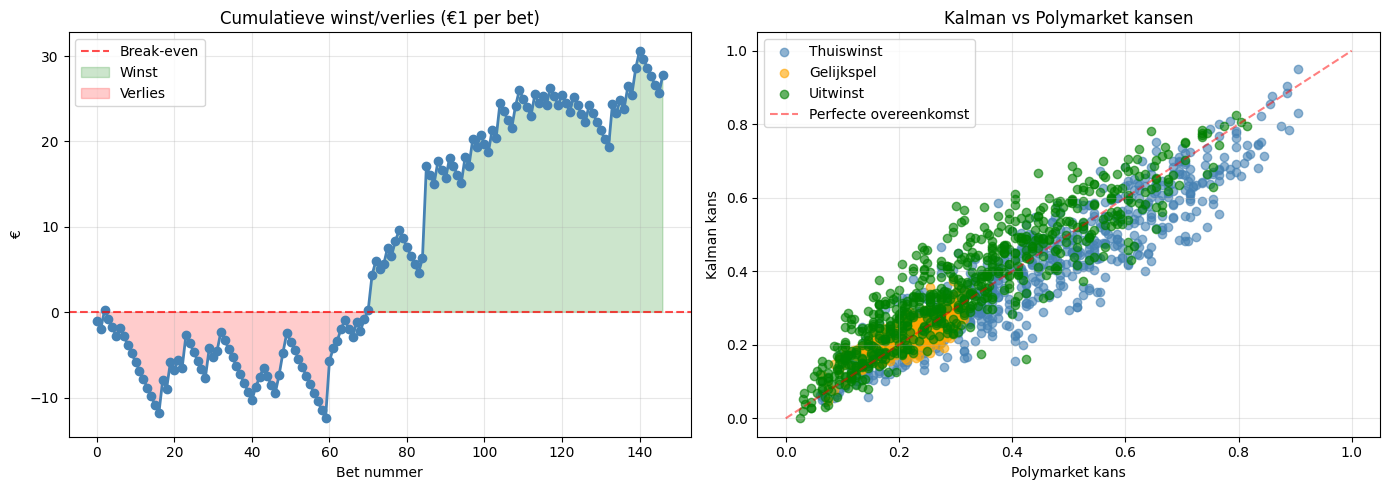

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulatieve winst
axes[0].plot(range(len(results_df)), results_df['cumulative'], marker='o', linewidth=2, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.7, label='Break-even')
axes[0].fill_between(range(len(results_df)), results_df['cumulative'], 0,
                      where=results_df['cumulative'] >= 0, alpha=0.2, color='green', label='Winst')
axes[0].fill_between(range(len(results_df)), results_df['cumulative'], 0,
                      where=results_df['cumulative'] < 0, alpha=0.2, color='red', label='Verlies')
axes[0].set_title('Cumulatieve winst/verlies (€1 per bet)')
axes[0].set_xlabel('Bet nummer')
axes[0].set_ylabel('€')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Kansen vergelijking: Kalman vs Polymarket
ax = axes[1]
x = range(len(sim))
ax.scatter(sim['prob_home'], sim['kalman_prob_home'], alpha=0.6, label='Thuiswinst', color='steelblue')
ax.scatter(sim['prob_draw'], sim['kalman_prob_draw'], alpha=0.6, label='Gelijkspel', color='orange')
ax.scatter(sim['prob_away'], sim['kalman_prob_away'], alpha=0.6, label='Uitwinst', color='green')
ax.plot([0,1],[0,1], 'r--', alpha=0.5, label='Perfecte overeenkomst')
ax.set_xlabel('Polymarket kans')
ax.set_ylabel('Kalman kans')
ax.set_title('Kalman vs Polymarket kansen')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kalman_betting_simulatie.png', dpi=150)
plt.show()

## Stap 7 — Vergelijking Kalman vs Polymarket accuracy

In [40]:
from sklearn.metrics import accuracy_score, f1_score, brier_score_loss

# Voorspelling Kalman: hoogste kans
sim['kalman_pred'] = sim[['kalman_prob_home','kalman_prob_draw','kalman_prob_away']].idxmax(axis=1)
sim['kalman_pred'] = sim['kalman_pred'].map({
    'kalman_prob_home': 'H',
    'kalman_prob_draw': 'D',
    'kalman_prob_away': 'A'
})

# Voorspelling Polymarket: hoogste kans
sim['poly_pred'] = sim[['prob_home','prob_draw','prob_away']].idxmax(axis=1)
sim['poly_pred'] = sim['poly_pred'].map({
    'prob_home': 'H',
    'prob_draw': 'D',
    'prob_away': 'A'
})

print('=== ACCURACY ===')
print(f'Kalman:     {accuracy_score(sim["result"], sim["kalman_pred"]):.3f}')
print(f'Polymarket: {accuracy_score(sim["result"], sim["poly_pred"]):.3f}')

print('\n=== F1 MACRO ===')
print(f'Kalman:     {f1_score(sim["result"], sim["kalman_pred"], average="macro"):.3f}')
print(f'Polymarket: {f1_score(sim["result"], sim["poly_pred"], average="macro"):.3f}')

print('\n=== BRIER SCORE (lager = beter gekalibreerd) ===')
for outcome, label in [('H','Thuis'), ('D','Gelijk'), ('A','Uit')]:
    actual_bin = (sim['result'] == outcome).astype(int)
    brier_k = brier_score_loss(actual_bin, sim[f'kalman_prob_{"home" if outcome=="H" else "draw" if outcome=="D" else "away"}'])
    brier_p = brier_score_loss(actual_bin, sim[f'prob_{"home" if outcome=="H" else "draw" if outcome=="D" else "away"}'])
    print(f'{label:8s} — Kalman: {brier_k:.3f}  Polymarket: {brier_p:.3f}')

=== ACCURACY ===
Kalman:     0.528
Polymarket: 0.531

=== F1 MACRO ===
Kalman:     0.402
Polymarket: 0.400

=== BRIER SCORE (lager = beter gekalibreerd) ===
Thuis    — Kalman: 0.211  Polymarket: 0.210
Gelijk   — Kalman: 0.191  Polymarket: 0.190
Uit      — Kalman: 0.192  Polymarket: 0.191


In [42]:
# ── CHECK 1: DATA LEAKAGE ────────────────────────────────────────────────────
print('=== LEAKAGE CHECK ===')
print('Kalman gebruikt pre-match state (voor de update) dus geen directe leakage.')
print('Check: correlatie tussen Kalman xG pred en werkelijke goals:')
corr_h = merged['kalman_xg_pred_home'].corr(merged['home_goals'].astype(float))
corr_a = merged['kalman_xg_pred_away'].corr(merged['away_goals'].astype(float))
print(f'Correlatie pred home xG vs werkelijke goals: {corr_h:.3f}')
print(f'Correlatie pred away xG vs werkelijke goals: {corr_a:.3f}')
print('(>0.6 = mogelijk leakage, ~0.2-0.4 = normaal voor goede voorspeller)')

# ── CHECK 2: VERSCHILLENDE DREMPELS ─────────────────────────────────────────
print('\n=== ROI BIJ VERSCHILLENDE DREMPELS ===')
sim_test = sim.copy()
for drempel in [0.0, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20]:
    winst = 0
    bets  = 0
    for _, row in sim_test.iterrows():
        edges = {
            'H': row['kalman_prob_home'] - row['prob_home'],
            'D': row['kalman_prob_draw'] - row['prob_draw'],
            'A': row['kalman_prob_away'] - row['prob_away'],
        }
        best = max(edges, key=edges.get)
        if edges[best] >= drempel:
            bets += 1
            poly_prob = row[f'prob_{"home" if best=="H" else "draw" if best=="D" else "away"}']
            odds = 1 / poly_prob
            winst += (odds - 1) if row['result'] == best else -1
    roi = winst/bets*100 if bets > 0 else 0
    print(f'Drempel {drempel:.2f} → {bets:3d} bets | ROI: {roi:+.1f}%')

# ── CHECK 3: RANDOM BASELINE ─────────────────────────────────────────────────
print('\n=== RANDOM BASELINE (1000x simulatie) ===')
import random
random.seed(42)
random_rois = []
for _ in range(1000):
    winst = 0
    for _, row in sim_test.iterrows():
        bet = random.choice(['H','D','A'])
        poly_prob = row[f'prob_{"home" if bet=="H" else "draw" if bet=="D" else "away"}']
        odds = 1 / poly_prob
        winst += (odds - 1) if row['result'] == bet else -1
    random_rois.append(winst/len(sim_test)*100)

model_roi = bankroll/bets_placed*100 if bets_placed > 0 else 0
p5  = np.percentile(random_rois, 2.5)
p95 = np.percentile(random_rois, 97.5)

print(f'Gemiddelde random ROI:  {np.mean(random_rois):+.1f}%')
print(f'Std random ROI:         {np.std(random_rois):.1f}%')
print(f'95% interval:           [{p5:+.1f}%, {p95:+.1f}%]')
print(f'Jouw model ROI:         {model_roi:+.1f}%')
print()
if p5 < model_roi < p95:
    print('⚠️  ROI valt BINNEN random interval — niet statistisch significant bij deze steekproef')
else:
    print('✅ ROI valt BUITEN random interval — statistisch significant op 95% niveau')

=== LEAKAGE CHECK ===
Kalman gebruikt pre-match state (voor de update) dus geen directe leakage.
Check: correlatie tussen Kalman xG pred en werkelijke goals:
Correlatie pred home xG vs werkelijke goals: 0.325
Correlatie pred away xG vs werkelijke goals: 0.333
(>0.6 = mogelijk leakage, ~0.2-0.4 = normaal voor goede voorspeller)

=== ROI BIJ VERSCHILLENDE DREMPELS ===
Drempel 0.00 → 664 bets | ROI: +16.5%
Drempel 0.02 → 582 bets | ROI: +17.4%
Drempel 0.05 → 359 bets | ROI: +16.7%
Drempel 0.08 → 207 bets | ROI: +14.3%
Drempel 0.10 → 147 bets | ROI: +18.9%
Drempel 0.15 →  45 bets | ROI: +16.1%
Drempel 0.20 →  17 bets | ROI: +12.5%

=== RANDOM BASELINE (1000x simulatie) ===
Gemiddelde random ROI:  +0.6%
Std random ROI:         6.6%
95% interval:           [-12.0%, +13.8%]
Jouw model ROI:         +18.9%

✅ ROI valt BUITEN random interval — statistisch significant op 95% niveau


Aantal away bets:       76
Win rate:               38.2%
Gemiddelde odds:        4.40
Gemiddelde edge:        0.143

Flat stake ROI:         38.4%
Compound (Kelly) ROI:   109.5%
Eindbankroll Kelly:     €2094.79


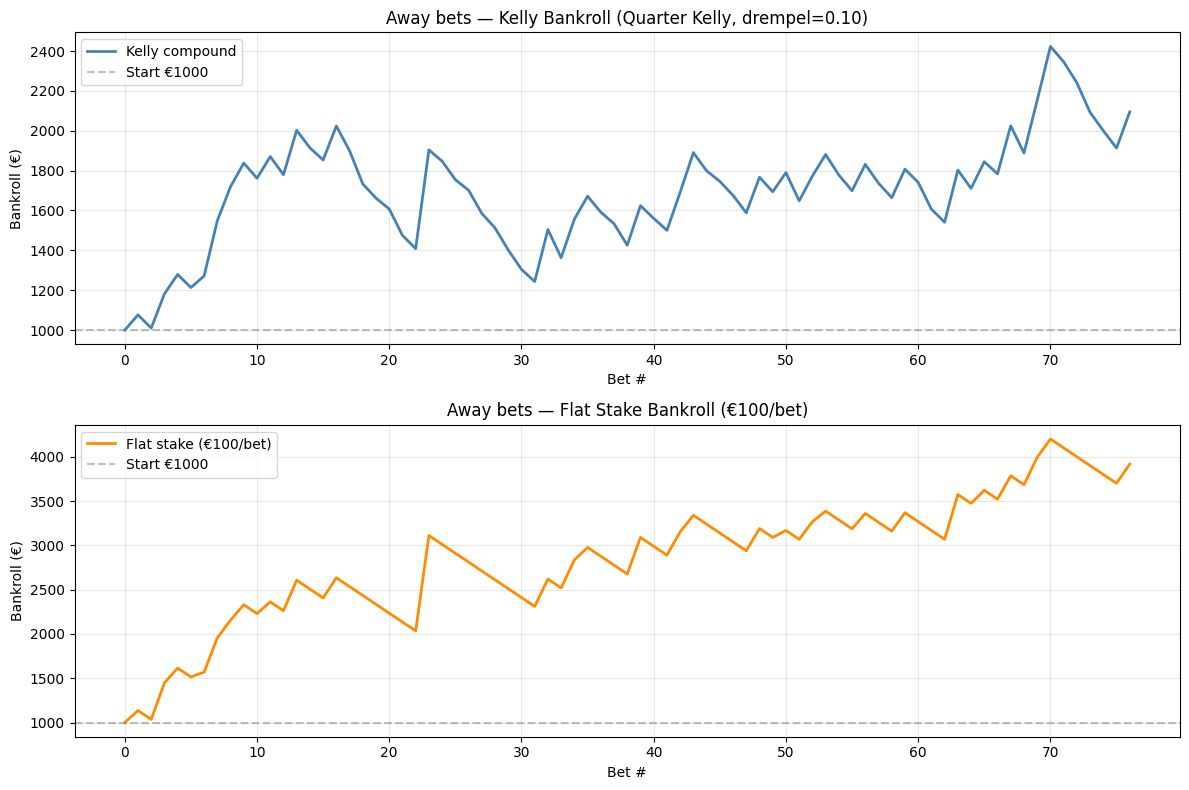

In [54]:
# === ALLEEN AWAY BETS ===
bets_A = bets_df[bets_df['outcome'] == 'A'].copy().reset_index(drop=True)

# --- Compound (Kelly) ---
bankroll = 1000
history_compound = [bankroll]
for _, bet in bets_A.iterrows():
    stake = bankroll * kelly_stake(bet['prob_model'], bet['odds'])
    if bet['won']:
        bankroll += stake * (bet['odds'] - 1)
    else:
        bankroll -= stake
    history_compound.append(bankroll)

roi_compound = (history_compound[-1] - 1000) / 1000 * 100

# --- Flat stake ---
flat_profit = 0
for _, bet in bets_A.iterrows():
    if bet['won']:
        flat_profit += (bet['odds'] - 1) * 100
    else:
        flat_profit -= 100

roi_flat = flat_profit / (len(bets_A) * 100) * 100

# --- Print ---
print(f"Aantal away bets:       {len(bets_A)}")
print(f"Win rate:               {bets_A['won'].mean()*100:.1f}%")
print(f"Gemiddelde odds:        {bets_A['odds'].mean():.2f}")
print(f"Gemiddelde edge:        {bets_A['edge'].mean():.3f}")
print(f"")
print(f"Flat stake ROI:         {roi_flat:.1f}%")
print(f"Compound (Kelly) ROI:   {roi_compound:.1f}%")
print(f"Eindbankroll Kelly:     €{history_compound[-1]:.2f}")

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(history_compound, linewidth=2, color='steelblue', label='Kelly compound')
ax1.axhline(1000, color='gray', linestyle='--', alpha=0.5, label='Start €1000')
ax1.set_title(f'Away bets — Kelly Bankroll (Quarter Kelly, drempel=0.10)')
ax1.set_xlabel('Bet #')
ax1.set_ylabel('Bankroll (€)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Flat stake curve
flat_history = [1000]
running = 1000
for _, bet in bets_A.iterrows():
    if bet['won']:
        running += (bet['odds'] - 1) * 100
    else:
        running -= 100
    flat_history.append(running)

ax2.plot(flat_history, linewidth=2, color='darkorange', label='Flat stake (€100/bet)')
ax2.axhline(1000, color='gray', linestyle='--', alpha=0.5, label='Start €1000')
ax2.set_title(f'Away bets — Flat Stake Bankroll (€100/bet)')
ax2.set_xlabel('Bet #')
ax2.set_ylabel('Bankroll (€)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kelly_away_simulatie.png', dpi=150)
plt.show()